# **KUIS PEMBELAJARAN MESIN**

**Nama**  : Mufliha Hafsyah Shahieza <br>
**NIM**   : 244107020147 <br>
**Kelas** : TI-3G

---

# **Komparasi DBSCAN Euclidean vs DBSCAN Manhattan vs DBSCAN Cosine**


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler

path = '/content/drive/MyDrive/ML2026/diabetes_012_health_indicators_BRFSS2015.csv'
df = pd.read_csv(path)

df = df[df['Diabetes_012'] != 1]
df = df.drop(columns=['Income', 'Cluster'], errors='ignore')
df = df.drop_duplicates().reset_index(drop=True)

y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)

X_scaled = StandardScaler().fit_transform(df_features.values)

rng = np.random.RandomState(42)
idx = np.sort(rng.choice(len(X_scaled), size=10000, replace=False))
X_sample = X_scaled[idx]

print(df_features.shape)   # harus (208858, 20)
print(X_sample.shape)      # harus (10000, 20)
print(list(df_features.columns))

(208858, 20)
(10000, 20)
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']


In [6]:
import time, numpy as np, pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

MIN_PTS = 40   # 2 x jumlah fitur, sama untuk semua metrik

def kdist(X, metric, k=MIN_PTS):
    nn = NearestNeighbors(n_neighbors=k, metric=metric, algorithm='brute').fit(X)
    return np.sort(nn.kneighbors(X)[0][:, -1])

def run_dbscan(X, metric, eps, min_samples=MIN_PTS):
    t0 = time.perf_counter()
    lab = DBSCAN(eps=eps, min_samples=min_samples, metric=metric,
                 algorithm='brute', n_jobs=-1).fit_predict(X)
    waktu = time.perf_counter() - t0
    mask = lab != -1
    n_cl = len(set(lab[mask]))
    sizes = np.bincount(lab[mask]) if n_cl else np.array([0])
    row = {
        'Metrik': metric, 'eps': round(eps, 4), 'MinPts': min_samples,
        'Klaster': n_cl,
        'Klaster >=1%': int((sizes >= 0.01 * len(X)).sum()),
        'Noise (n)': int((~mask).sum()),
        'Noise (%)': round(100 * (~mask).mean(), 2),
        'Klaster terbesar (%)': round(100 * sizes.max() / len(X), 2),
        'Waktu (s)': round(waktu, 2),
    }
    if n_cl >= 2:
        row['Silhouette (metrik sendiri)'] = silhouette_score(X[mask], lab[mask], metric=metric)
        row['Silhouette (euclidean)']      = silhouette_score(X[mask], lab[mask], metric='euclidean')
        row['DBI'] = davies_bouldin_score(X[mask], lab[mask])
        row['CHI'] = calinski_harabasz_score(X[mask], lab[mask])
    return row, lab

In [7]:
hasil, labels_store = [], {}
for metric in ['euclidean', 'manhattan', 'cosine']:
    kd = kdist(X_sample, metric)
    for p in [50, 60, 70, 80, 90, 95]:
        eps = float(np.percentile(kd, p))
        row, lab = run_dbscan(X_sample, metric, eps)
        row['persentil'] = p
        hasil.append(row)
        labels_store[(metric, p)] = lab
        print(metric, p, round(eps, 4), '->', row['Klaster'], 'klaster, noise', row['Noise (%)'], '%')

sweep = pd.DataFrame(hasil)
sweep

euclidean 50 2.769 -> 6 klaster, noise 31.18 %
euclidean 60 3.0908 -> 6 klaster, noise 23.49 %
euclidean 70 3.4479 -> 5 klaster, noise 14.98 %
euclidean 80 3.8596 -> 5 klaster, noise 8.01 %
euclidean 90 4.4344 -> 3 klaster, noise 3.08 %
euclidean 95 4.9454 -> 1 klaster, noise 0.98 %
manhattan 50 4.9644 -> 2 klaster, noise 27.79 %
manhattan 60 5.7226 -> 1 klaster, noise 19.61 %
manhattan 70 6.6673 -> 1 klaster, noise 11.34 %
manhattan 80 7.7495 -> 1 klaster, noise 5.62 %
manhattan 90 9.3462 -> 1 klaster, noise 1.92 %
manhattan 95 10.8542 -> 1 klaster, noise 0.46 %
cosine 50 0.2483 -> 4 klaster, noise 11.9 %
cosine 60 0.2658 -> 3 klaster, noise 6.04 %
cosine 70 0.2845 -> 1 klaster, noise 2.25 %
cosine 80 0.3084 -> 1 klaster, noise 0.49 %
cosine 90 0.3384 -> 1 klaster, noise 0.02 %
cosine 95 0.3595 -> 1 klaster, noise 0.0 %


,Metrik,eps,MinPts,Klaster,Klaster >=1%,Noise (n),Noise (%),Klaster terbesar (%),Waktu (s),Silhouette (metrik sendiri),Silhouette (euclidean),DBI,CHI,persentil
0,euclidean,2.7690,40,6,5,3118,31.18,57.56,1.00,0.166362,0.166362,1.455135,355.501900,50
1,euclidean,3.0908,40,6,6,2349,23.49,61.51,1.06,0.170197,0.170197,1.573250,424.179803,60
2,euclidean,3.4479,40,5,4,1498,14.98,74.63,0.62,0.206017,0.206017,1.452823,377.028600,70
3,euclidean,3.8596,40,5,5,801,8.01,78.32,1.15,0.201363,0.201363,1.553247,472.916022,80
4,euclidean,4.4344,40,3,3,308,3.08,89.97,2.17,0.227392,0.227392,1.565536,507.822424,90
5,euclidean,4.9454,40,1,1,98,0.98,99.02,4.11,NaN,NaN,NaN,NaN,95
6,manhattan,4.9644,40,2,2,2779,27.79,70.50,2.24,0.215542,0.267991,1.194762,339.055912,50
7,manhattan,5.7226,40,1,1,1961,19.61,80.39,2.96,NaN,NaN,NaN,NaN,60
8,manhattan,6.6673,40,1,1,1134,11.34,88.66,3.50,NaN,NaN,NaN,NaN,70
9,manhattan,7.7495,40,1,1,562,5.62,94.38,2.48,NaN,NaN,NaN,NaN,80


In [10]:
kand = sweep[(sweep['Klaster >=1%'] >= 2) & (sweep['Noise (%)'] <= 30)]
final = (kand.sort_values('Silhouette (euclidean)', ascending=False)
             .groupby('Metrik').head(1)
             .set_index('Metrik').loc[['euclidean', 'manhattan', 'cosine']])
final.to_csv('tabel_komparasi_dbscan.csv')
final

,eps,MinPts,Klaster,Klaster >=1%,Noise (n),Noise (%),Klaster terbesar (%),Waktu (s),Silhouette (metrik sendiri),Silhouette (euclidean),DBI,CHI,persentil
Metrik,,,,,,,,,,,,,
euclidean,4.4344,40,3,3,308,3.08,89.97,2.17,0.227392,0.227392,1.565536,507.822424,90
manhattan,4.9644,40,2,2,2779,27.79,70.50,2.24,0.215542,0.267991,1.194762,339.055912,50
cosine,0.2658,40,3,3,604,6.04,79.87,2.09,0.091977,0.159632,2.136715,582.533548,60


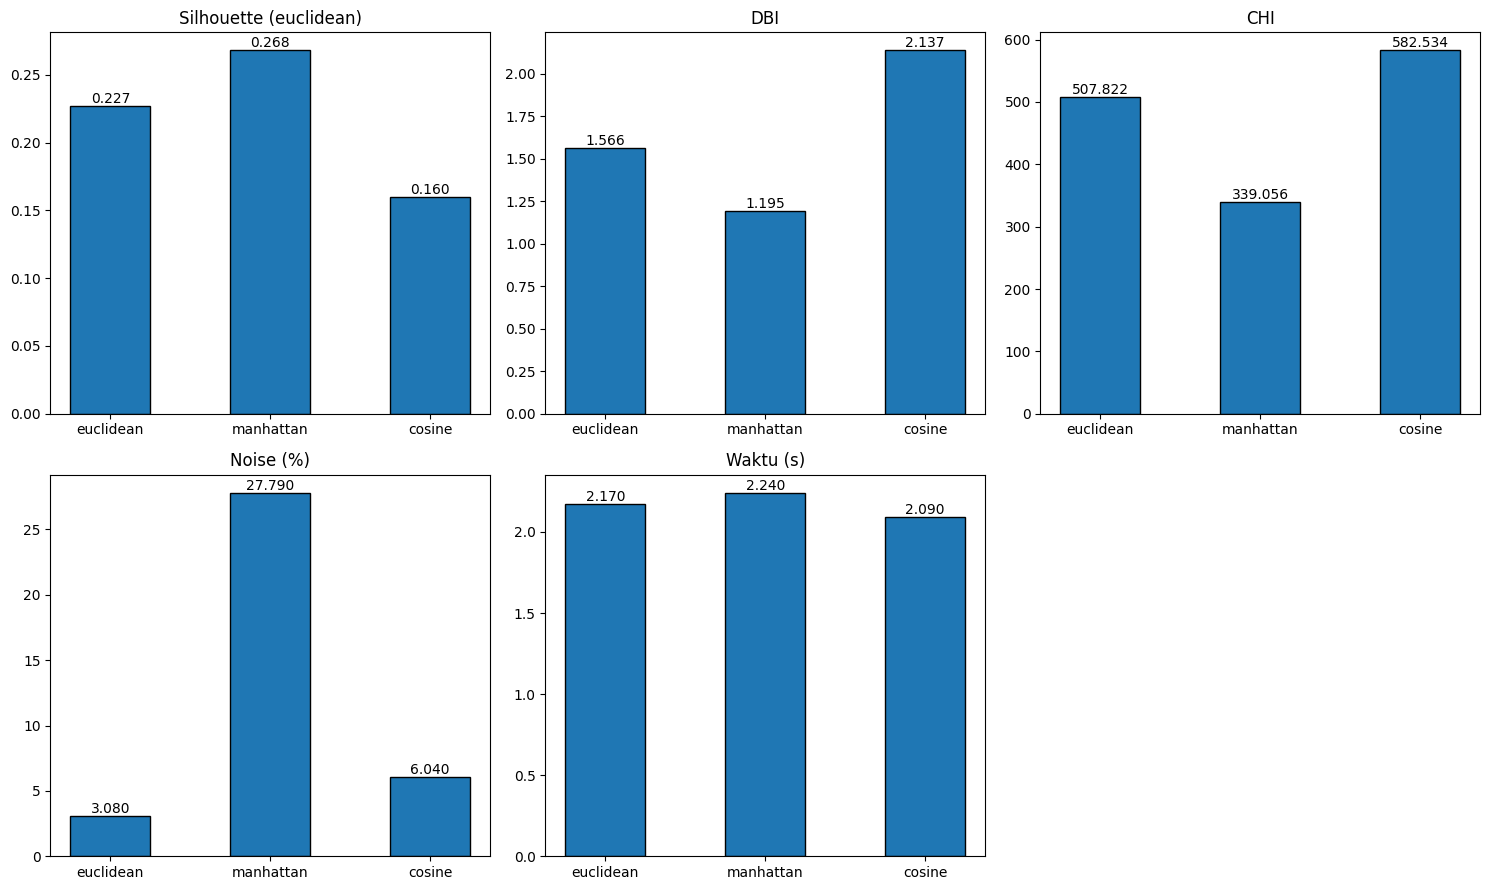

In [11]:
import matplotlib.pyplot as plt

cols = ['Silhouette (euclidean)', 'DBI', 'CHI', 'Noise (%)', 'Waktu (s)']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, c in zip(axes.flat, cols):
    vals = final[c].astype(float)
    bars = ax.bar(vals.index, vals.values, edgecolor='black', width=0.5)
    ax.set_title(c)
    for b in bars:
        ax.annotate(f'{b.get_height():.3f}',
                    (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha='center', va='bottom', fontsize=10)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('dbscan_metrics_barchart.png', dpi=300)
plt.show()

euclidean | eps 4.4344 | klaster 3 | noise 308
manhattan | eps 4.9644 | klaster 2 | noise 2779
cosine | eps 0.2658 | klaster 3 | noise 604


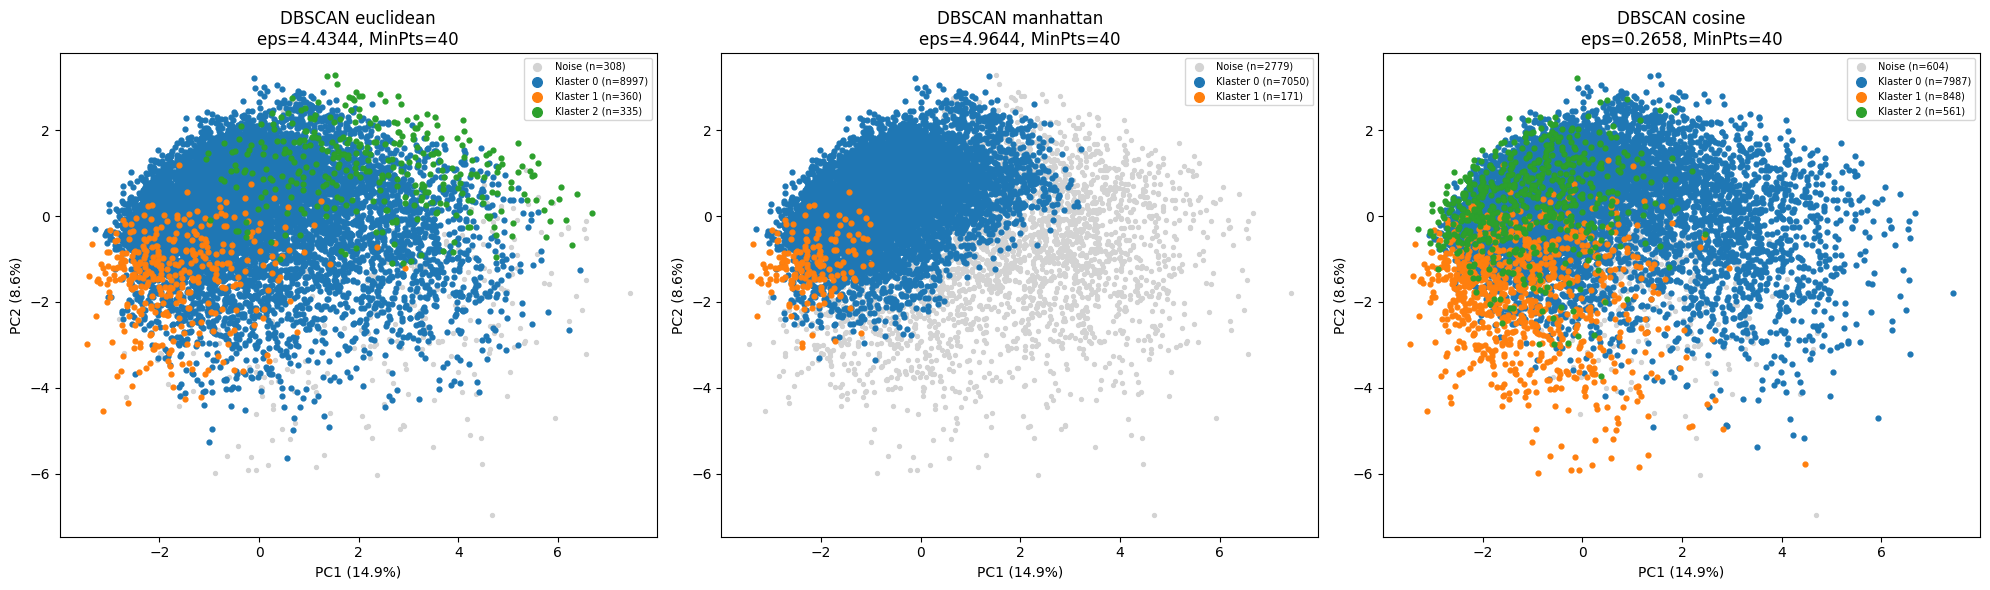

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_sample)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, metric in zip(axes, ['euclidean', 'manhattan', 'cosine']):
    r = final.loc[metric]
    p = int(r['persentil'])

    # hitung ulang eps persis seperti di sweep, lalu jalankan DBSCAN lagi
    eps = float(np.percentile(kdist(X_sample, metric), p))
    row, lab = run_dbscan(X_sample, metric, eps)
    print(metric, '| eps', round(eps, 4), '| klaster', row['Klaster'], '| noise', row['Noise (n)'])

    noise = lab == -1
    ax.scatter(X2[noise, 0], X2[noise, 1], c='lightgrey', s=8,
               label=f'Noise (n={noise.sum()})')
    for k in sorted(set(lab) - {-1}):
        m = lab == k
        ax.scatter(X2[m, 0], X2[m, 1], s=12, label=f'Klaster {k} (n={m.sum()})')
    ax.set_title(f"DBSCAN {metric}\neps={r['eps']}, MinPts={int(r['MinPts'])}")
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.savefig('dbscan_pca_comparison.png', dpi=300)
plt.show()